In [1]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from matplotlib import font_manager, colors
import itertools

In [2]:
def set_minorticks(ax: plt.axes) -> None: 
    ax.grid(axis='both', which='both', ls='--', lw='0.5', c='#808080')
    ax.minorticks_on()
    ax.ticklabel_format(axis='y', scilimits=[-3,3])
    ax.ticklabel_format(axis='x', useOffset=False)

def set_ax_label(ax: plt.axes, x, y) -> None:
    ax.set_xlabel(x, fontname='Arial', **label_opt, )
    ax.set_ylabel(y, fontname='Arial', **label_opt, )

['01_APL_20_to_-20_morning', '02_APL_-20_to_20_morning']
левая граница (от 20 до -20): -13.597
левая граница (от -20 до 20): -13.601
правая граница (от 20 до -20): 8.018
правая граница (от -20 до 20): 7.999
центр = -2.80


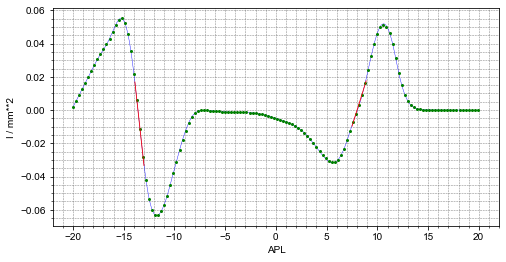

In [34]:
#func
def func(x, A, B, ):
    #y = A*np.exp(-1*B*x**2)
    #y = A*(np.exp(x*(1+B*x**2)/C)-1) + x/(M*(1+N*abs(x))) + K
    #y = A*(np.exp(x/M)-1) + N
    #y = A*x**2 + B*x + C
    y = A*x + B
    return y

#data
#1N4007_0_to_1_lim_1mA
#1N4007_-1_to_0_lim_1uA
#1N4007_-1_to_1_lim_1uA
delim = '\t'
x_d, y_d = [], []

data = {}

files = ['01_APL_20_to_-20_morning', '02_APL_-20_to_20_morning']
print(files)

#filename = 'Tonghui 2025-09-24 17-32-32'
for filename in files:
    data[filename] = {'x':[], 'y':[]}
    with open(filename + '.txt') as f:
        next(f)
        for line in f:
            rawline = line.split(delim)
            cx = float(rawline[2])
            cy = float(rawline[6])
            data[filename]['x'].append(cx)
            data[filename]['y'].append(cy)
            x_d.append(cx)
            y_d.append(cy)


#print(len(x_d))
#cut_start, cut_end = 400, 500
#x_data, y_data = np.array(x_d[cut_start:cut_end]), np.array(y_d[cut_start:cut_end])


'''
#Perform the curve fit
cheat = [1.31551E-8, 0.87, 0.03974, 1.1E7, 0.95, 4.5E-9]
aid = [1e-8, 0.9, 0.04, 1e7, 1, 5e-9]
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

#Вывод параметров фита
#print(r'cheat ='), print(cheat)
#print(r'aid ='), print(aid)
#print(r'opt ='), print(popt)'''

#8888888888888888888888888888888888888888888888888888888888888888888888888888888888888888

#фигуры
fig, ax = plt.subplots(figsize=(8, 4), )

#custom_norm = colors.SymLogNorm(linthresh=0.1, linscale=0.5, base=10, vmin=y_data.min(), vmax=y_data.max())

#настраиваем деления
set_minorticks(ax)

#подписываем оси
label_opt = {'labelpad':4, 'fontsize':10, }
set_ax_label(ax, 'APL', 'I / mm**2', )

#меняем шрифт тиков
ticks_font = font_manager.FontProperties(family='Arial', size=10, weight='light')
xticks, yticks = ax.get_xticklabels(), ax.get_yticklabels()
for xtick, ytick in itertools.product(xticks, yticks):
    xtick.set_fontproperties(ticks_font)
    ytick.set_fontproperties(ticks_font)

raw_options = {'linestyle':'solid', 'linewidth':0.4, 'c':'b'}
raw2_options = {'linestyle':'none', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'g', 'markevery': 3}
raw3_options = {'linestyle':'solid', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'r'}
fit_options = {'linestyle':'solid', 'linewidth':0.8, 'c':'r'}
raw0 = data[files[0]]['y']
raw1 = data[files[1]]['y']
norm0 = [i/min(data[files[0]]['y']) for i in data[files[0]]['y']]
dy_dx_0 = np.gradient(norm0, data[files[0]]['x'])
dy_dx_0 = savgol_filter(norm0, window_length=45, polyorder=3, deriv=2, delta=np.diff(data[files[0]]['x'])[0])
norm1 = [i/min(data[files[1]]['y']) for i in data[files[1]]['y']]
dy_dx_1 = np.gradient(norm1, data[files[1]]['x'])
dy_dx_1 = savgol_filter(norm1, window_length=45, polyorder=3, deriv=2, delta=np.diff(data[files[1]]['x'])[0])
# window_length — размер окна (нечетное число), polyorder — степень полинома
#y_smooth_0 = savgol_filter(norm0, window_length=15, polyorder=3)

# Бонус: фильтр может СРАЗУ вернуть сглаженную производную первого порядка (deriv=1)
# dy_dx = savgol_filter(y, window_length=15, polyorder=3, deriv=1, delta=np.diff(x)[0])

fits = {}
center = []

#====================================================================================
cut_start, cut_end = 400-70, 400-60
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['left_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================
cut_start, cut_end = 60, 70
x_data, y_data = np.array(data[files[1]]['x'][cut_start:cut_end]), np.array(dy_dx_1[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от -20 до 20): {-b_fit/a_fit:.3f}')
fits['left_1'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================



#====================================================================================
cut_start, cut_end = 400-290, 400-275
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['right_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================
cut_start, cut_end = 275, 290
x_data, y_data = np.array(data[files[1]]['x'][cut_start:cut_end]), np.array(dy_dx_1[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от -20 до 20): {-b_fit/a_fit:.3f}')
fits['right_1'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================

print(f'центр = {np.mean(center):.2f}')

abs0 = [abs(i) for i in data[files[0]]['y']]
abs1 = [abs(i) for i in data[files[1]]['y']]
#plot1, = ax.plot(data[files[0]]['x'], norm0, **raw_options, label='raw', )
plot1d, = ax.plot(data[files[0]]['x'], dy_dx_0, **raw_options, label='raw', )
#plot2, = ax.plot(data[files[1]]['x'], norm1, **raw2_options, label='raw', )
plot2d, = ax.plot(data[files[1]]['x'], dy_dx_1, **raw2_options, label='raw', )
#plot3, = ax.plot(data[files[2]]['x'], data[files[2]]['y'], **raw3_options, label='raw', )
#plot1, = ax.plot(x_data, abs(y_data), **raw_options, label='raw', )
#plot2, = ax.plot(x_data, func(x_data, a_fit, b_fit), **fit_options, label='fit', )
plot2, = ax.plot(fits['left_0'][0], func(*fits['left_0']), **fit_options, label='fit', )
plot2, = ax.plot(fits['right_1'][0], func(*fits['right_1']), **fit_options, label='fit', )

#plt.yscale('log')
#plt.yscale('symlog', linthresh=1e-10, linscale=0.2, )

plt.show()


['01_APL_20_to_-20', '02_APL_-20_to_20']
левая граница (от 20 до -20): -10.439
левая граница (от -20 до 20): -10.425
правая граница (от 20 до -20): 12.800
правая граница (от -20 до 20): 12.814
центр = 1.19


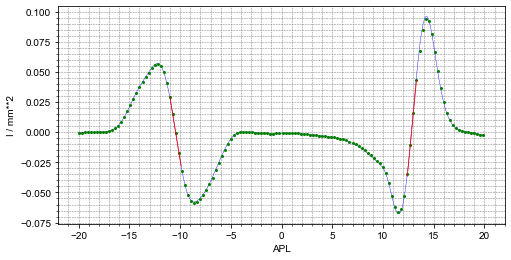

In [35]:
#func
def func(x, A, B, ):
    #y = A*np.exp(-1*B*x**2)
    #y = A*(np.exp(x*(1+B*x**2)/C)-1) + x/(M*(1+N*abs(x))) + K
    #y = A*(np.exp(x/M)-1) + N
    #y = A*x**2 + B*x + C
    y = A*x + B
    return y

#data
#1N4007_0_to_1_lim_1mA
#1N4007_-1_to_0_lim_1uA
#1N4007_-1_to_1_lim_1uA
delim = '\t'
x_d, y_d = [], []

data = {}

files = ['01_APL_20_to_-20', '02_APL_-20_to_20']
print(files)

#filename = 'Tonghui 2025-09-24 17-32-32'
for filename in files:
    data[filename] = {'x':[], 'y':[]}
    with open(filename + '.txt') as f:
        next(f)
        for line in f:
            rawline = line.split(delim)
            cx = float(rawline[2])
            cy = float(rawline[6])
            data[filename]['x'].append(cx)
            data[filename]['y'].append(cy)
            x_d.append(cx)
            y_d.append(cy)


#print(len(x_d))
#cut_start, cut_end = 400, 500
#x_data, y_data = np.array(x_d[cut_start:cut_end]), np.array(y_d[cut_start:cut_end])


'''
#Perform the curve fit
cheat = [1.31551E-8, 0.87, 0.03974, 1.1E7, 0.95, 4.5E-9]
aid = [1e-8, 0.9, 0.04, 1e7, 1, 5e-9]
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

#Вывод параметров фита
#print(r'cheat ='), print(cheat)
#print(r'aid ='), print(aid)
#print(r'opt ='), print(popt)'''

#8888888888888888888888888888888888888888888888888888888888888888888888888888888888888888

#фигуры
fig, ax = plt.subplots(figsize=(8, 4), )

#custom_norm = colors.SymLogNorm(linthresh=0.1, linscale=0.5, base=10, vmin=y_data.min(), vmax=y_data.max())

#настраиваем деления
set_minorticks(ax)

#подписываем оси
label_opt = {'labelpad':4, 'fontsize':10, }
set_ax_label(ax, 'APL', 'I / mm**2', )

#меняем шрифт тиков
ticks_font = font_manager.FontProperties(family='Arial', size=10, weight='light')
xticks, yticks = ax.get_xticklabels(), ax.get_yticklabels()
for xtick, ytick in itertools.product(xticks, yticks):
    xtick.set_fontproperties(ticks_font)
    ytick.set_fontproperties(ticks_font)

raw_options = {'linestyle':'solid', 'linewidth':0.4, 'c':'b'}
raw2_options = {'linestyle':'none', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'g', 'markevery': 3}
raw3_options = {'linestyle':'solid', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'r'}
fit_options = {'linestyle':'solid', 'linewidth':0.8, 'c':'r'}
raw0 = data[files[0]]['y']
raw1 = data[files[1]]['y']
norm0 = [i/min(data[files[0]]['y']) for i in data[files[0]]['y']]
dy_dx_0 = np.gradient(norm0, data[files[0]]['x'])
dy_dx_0 = savgol_filter(norm0, window_length=45, polyorder=3, deriv=2, delta=np.diff(data[files[0]]['x'])[0])
norm1 = [i/min(data[files[1]]['y']) for i in data[files[1]]['y']]
dy_dx_1 = np.gradient(norm1, data[files[1]]['x'])
dy_dx_1 = savgol_filter(norm1, window_length=45, polyorder=3, deriv=2, delta=np.diff(data[files[1]]['x'])[0])
# window_length — размер окна (нечетное число), polyorder — степень полинома
#y_smooth_0 = savgol_filter(norm0, window_length=15, polyorder=3)

# Бонус: фильтр может СРАЗУ вернуть сглаженную производную первого порядка (deriv=1)
# dy_dx = savgol_filter(y, window_length=15, polyorder=3, deriv=1, delta=np.diff(x)[0])

fits = {}
center = []

xstart, xend = 89, 101
#====================================================================================
cut_start, cut_end = 400-xend, 400-xstart
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['left_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================
cut_start, cut_end = xstart, xend
x_data, y_data = np.array(data[files[1]]['x'][cut_start:cut_end]), np.array(dy_dx_1[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от -20 до 20): {-b_fit/a_fit:.3f}')
fits['left_1'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================


xstart, xend = 324, 334
#====================================================================================
cut_start, cut_end = 400-xend, 400-xstart
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['right_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================
cut_start, cut_end = xstart, xend
x_data, y_data = np.array(data[files[1]]['x'][cut_start:cut_end]), np.array(dy_dx_1[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от -20 до 20): {-b_fit/a_fit:.3f}')
fits['right_1'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================

print(f'центр = {np.mean(center):.2f}')

abs0 = [abs(i) for i in data[files[0]]['y']]
abs1 = [abs(i) for i in data[files[1]]['y']]
#plot1, = ax.plot(data[files[0]]['x'], norm0, **raw_options, label='raw', )
plot1d, = ax.plot(data[files[0]]['x'], dy_dx_0, **raw_options, label='raw', )
#plot2, = ax.plot(data[files[1]]['x'], norm1, **raw2_options, label='raw', )
plot2d, = ax.plot(data[files[1]]['x'], dy_dx_1, **raw2_options, label='raw', )
#plot3, = ax.plot(data[files[2]]['x'], data[files[2]]['y'], **raw3_options, label='raw', )
#plot1, = ax.plot(x_data, abs(y_data), **raw_options, label='raw', )
#plot2, = ax.plot(x_data, func(x_data, a_fit, b_fit), **fit_options, label='fit', )
plot2, = ax.plot(fits['left_0'][0], func(*fits['left_0']), **fit_options, label='fit', )
plot2, = ax.plot(fits['right_1'][0], func(*fits['right_1']), **fit_options, label='fit', )

#plt.yscale('log')
#plt.yscale('symlog', linthresh=1e-10, linscale=0.2, )

plt.show()


['05_APR_20_to_-20', '06_APR_-20_to_20']
Относительное дрожание шага: -0.000000000001%
левая граница (от 20 до -20): -13.495
левая граница (от -20 до 20): -13.526
правая граница (от 20 до -20): 10.228
правая граница (от -20 до 20): 10.179
центр = -1.65


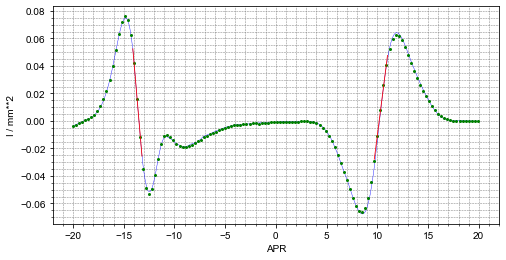

In [44]:
#func
def func(x, A, B, ):
    #y = A*np.exp(-1*B*x**2)
    #y = A*(np.exp(x*(1+B*x**2)/C)-1) + x/(M*(1+N*abs(x))) + K
    #y = A*(np.exp(x/M)-1) + N
    #y = A*x**2 + B*x + C
    y = A*x + B
    return y

#data
#1N4007_0_to_1_lim_1mA
#1N4007_-1_to_0_lim_1uA
#1N4007_-1_to_1_lim_1uA
delim = '\t'
x_d, y_d = [], []

data = {}

files = ['05_APR_20_to_-20', '06_APR_-20_to_20']
print(files)

#filename = 'Tonghui 2025-09-24 17-32-32'
for filename in files:
    data[filename] = {'x':[], 'y':[]}
    with open(filename + '.txt') as f:
        next(f)
        for line in f:
            rawline = line.split(delim)
            cx = float(rawline[3])
            cy = float(rawline[6])
            data[filename]['x'].append(cx)
            data[filename]['y'].append(cy)
            x_d.append(cx)
            y_d.append(cy)


#print(len(x_d))
#cut_start, cut_end = 400, 500
#x_data, y_data = np.array(x_d[cut_start:cut_end]), np.array(y_d[cut_start:cut_end])


'''
#Perform the curve fit
cheat = [1.31551E-8, 0.87, 0.03974, 1.1E7, 0.95, 4.5E-9]
aid = [1e-8, 0.9, 0.04, 1e7, 1, 5e-9]
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

#Вывод параметров фита
#print(r'cheat ='), print(cheat)
#print(r'aid ='), print(aid)
#print(r'opt ='), print(popt)'''

#8888888888888888888888888888888888888888888888888888888888888888888888888888888888888888

#фигуры
fig, ax = plt.subplots(figsize=(8, 4), )

#custom_norm = colors.SymLogNorm(linthresh=0.1, linscale=0.5, base=10, vmin=y_data.min(), vmax=y_data.max())

#настраиваем деления
set_minorticks(ax)

#подписываем оси
label_opt = {'labelpad':4, 'fontsize':10, }
set_ax_label(ax, 'APR', 'I / mm**2', )

#меняем шрифт тиков
ticks_font = font_manager.FontProperties(family='Arial', size=10, weight='light')
xticks, yticks = ax.get_xticklabels(), ax.get_yticklabels()
for xtick, ytick in itertools.product(xticks, yticks):
    xtick.set_fontproperties(ticks_font)
    ytick.set_fontproperties(ticks_font)

raw_options = {'linestyle':'solid', 'linewidth':0.4, 'c':'b'}
raw2_options = {'linestyle':'none', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'g', 'markevery': 3}
raw3_options = {'linestyle':'solid', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'r'}
fit_options = {'linestyle':'solid', 'linewidth':0.8, 'c':'r'}
raw0 = data[files[0]]['y']
raw1 = data[files[1]]['y']

wl = 35

'''steps = np.diff(data[files[0]]['x'])
relative_jitter = np.std(steps) / np.mean(steps)
print(f"Относительное дрожание шага: {relative_jitter*100:.12f}%")'''

norm0 = [i/min(data[files[0]]['y']) for i in data[files[0]]['y']]
dy_dx_0 = np.gradient(norm0, data[files[0]]['x'])
dy_dx_0 = savgol_filter(norm0, window_length=wl, polyorder=3, deriv=2, delta=np.diff(data[files[0]]['x'])[0])
norm1 = [i/min(data[files[1]]['y']) for i in data[files[1]]['y']]
dy_dx_1 = np.gradient(norm1, data[files[1]]['x'])
dy_dx_1 = savgol_filter(norm1, window_length=wl, polyorder=3, deriv=2, delta=np.diff(data[files[1]]['x'])[0])
# window_length — размер окна (нечетное число), polyorder — степень полинома
#y_smooth_0 = savgol_filter(norm0, window_length=15, polyorder=3)

# Бонус: фильтр может СРАЗУ вернуть сглаженную производную первого порядка (deriv=1)
# dy_dx = savgol_filter(y, window_length=15, polyorder=3, deriv=1, delta=np.diff(x)[0])

fits = {}
center = []

xstart, xend = 58, 68
#====================================================================================
cut_start, cut_end = 400-xend, 400-xstart
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['left_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================
cut_start, cut_end = xstart, xend
x_data, y_data = np.array(data[files[1]]['x'][cut_start:cut_end]), np.array(dy_dx_1[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от -20 до 20): {-b_fit/a_fit:.3f}')
fits['left_1'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================


xstart, xend = 297, 311
#====================================================================================
cut_start, cut_end = 400-xend, 400-xstart
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['right_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================
cut_start, cut_end = xstart, xend
x_data, y_data = np.array(data[files[1]]['x'][cut_start:cut_end]), np.array(dy_dx_1[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от -20 до 20): {-b_fit/a_fit:.3f}')
fits['right_1'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================

print(f'центр = {np.mean(center):.2f}')

abs0 = [abs(i) for i in data[files[0]]['y']]
abs1 = [abs(i) for i in data[files[1]]['y']]
#plot1, = ax.plot(data[files[0]]['x'], norm0, **raw_options, label='raw', )
plot1d, = ax.plot(data[files[0]]['x'], dy_dx_0, **raw_options, label='raw', )
#plot2, = ax.plot(data[files[1]]['x'], norm1, **raw2_options, label='raw', )
plot2d, = ax.plot(data[files[1]]['x'], dy_dx_1, **raw2_options, label='raw', )
#plot3, = ax.plot(data[files[2]]['x'], data[files[2]]['y'], **raw3_options, label='raw', )
#plot1, = ax.plot(x_data, abs(y_data), **raw_options, label='raw', )
#plot2, = ax.plot(x_data, func(x_data, a_fit, b_fit), **fit_options, label='fit', )
plot2, = ax.plot(fits['left_0'][0], func(*fits['left_0']), **fit_options, label='fit', )
plot2, = ax.plot(fits['right_1'][0], func(*fits['right_1']), **fit_options, label='fit', )

#plt.yscale('log')
#plt.yscale('symlog', linthresh=1e-10, linscale=0.2, )

plt.show()


левая граница (от 20 до -20): -2.850
центр = -2.85


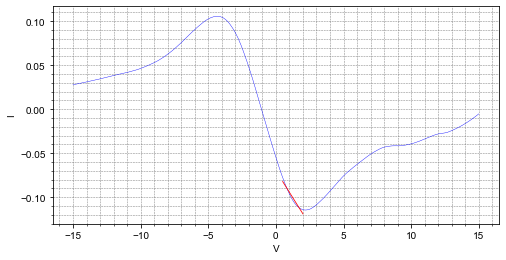

In [4]:
#func
def func(x, A, B, ):
    #y = A*np.exp(-1*B*x**2)
    #y = A*(np.exp(x*(1+B*x**2)/C)-1) + x/(M*(1+N*abs(x))) + K
    #y = A*(np.exp(x/M)-1) + N
    #y = A*x**2 + B*x + C
    y = A*x + B
    return y

#data
#1N4007_0_to_1_lim_1mA
#1N4007_-1_to_0_lim_1uA
#1N4007_-1_to_1_lim_1uA
delim = '\t'
x_d, y_d = [], []

data = {}

files = ['03_APT_15_to_-15', ]

#filename = 'Tonghui 2025-09-24 17-32-32'
for filename in files:
    data[filename] = {'x':[], 'y':[]}
    with open(filename + '.txt') as f:
        next(f)
        for line in f:
            rawline = line.split(delim)
            cx = float(rawline[1])
            cy = float(rawline[9])
            data[filename]['x'].append(cx)
            data[filename]['y'].append(cy)
            x_d.append(cx)
            y_d.append(cy)


#print(len(x_d))
#cut_start, cut_end = 400, 500
#x_data, y_data = np.array(x_d[cut_start:cut_end]), np.array(y_d[cut_start:cut_end])


'''
#Perform the curve fit
cheat = [1.31551E-8, 0.87, 0.03974, 1.1E7, 0.95, 4.5E-9]
aid = [1e-8, 0.9, 0.04, 1e7, 1, 5e-9]
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

#Вывод параметров фита
#print(r'cheat ='), print(cheat)
#print(r'aid ='), print(aid)
#print(r'opt ='), print(popt)'''

#8888888888888888888888888888888888888888888888888888888888888888888888888888888888888888

#фигуры
fig, ax = plt.subplots(figsize=(8, 4), )

#custom_norm = colors.SymLogNorm(linthresh=0.1, linscale=0.5, base=10, vmin=y_data.min(), vmax=y_data.max())

#настраиваем деления
set_minorticks(ax)

#подписываем оси
label_opt = {'labelpad':4, 'fontsize':10, }
set_ax_label(ax, 'V', 'I', )

#меняем шрифт тиков
ticks_font = font_manager.FontProperties(family='Arial', size=10, weight='light')
xticks, yticks = ax.get_xticklabels(), ax.get_yticklabels()
for xtick, ytick in itertools.product(xticks, yticks):
    xtick.set_fontproperties(ticks_font)
    ytick.set_fontproperties(ticks_font)

raw_options = {'linestyle':'solid', 'linewidth':0.4, 'c':'b'}
raw2_options = {'linestyle':'none', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'g', 'markevery': 3}
raw3_options = {'linestyle':'solid', 'linewidth':0.4, 'marker':'.', 'markersize':4, 'c':'r'}
fit_options = {'linestyle':'solid', 'linewidth':0.8, 'c':'r'}
raw0 = data[files[0]]['y']
norm0 = [i/min(data[files[0]]['y']) for i in data[files[0]]['y']]
dy_dx_0 = np.gradient(norm0, data[files[0]]['x'])
dy_dx_0 = savgol_filter(norm0, window_length=45, polyorder=3, deriv=1, delta=np.diff(data[files[0]]['x'])[0])

# window_length — размер окна (нечетное число), polyorder — степень полинома
#y_smooth_0 = savgol_filter(norm0, window_length=15, polyorder=3)

# Бонус: фильтр может СРАЗУ вернуть сглаженную производную первого порядка (deriv=1)
# dy_dx = savgol_filter(y, window_length=15, polyorder=3, deriv=1, delta=np.diff(x)[0])

fits = {}
center = []

#====================================================================================
cut_start, cut_end = 130, 146
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'левая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['left_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)
#====================================================================================

#====================================================================================
'''cut_start, cut_end = 100, 200
x_data, y_data = np.array(data[files[0]]['x'][cut_start:cut_end]), np.array(dy_dx_0[cut_start:cut_end])

#Perform the curve fit
popt, pcov = curve_fit(func, x_data, y_data, method='dogbox', ) #lm, dogbox, trf, p0=aid_2

#Extract the optimal parameters
a_fit, b_fit, = popt

print(f'правая граница (от 20 до -20): {-b_fit/a_fit:.3f}')

fits['right_0'] = [x_data, a_fit, b_fit]
center.append(-b_fit/a_fit)'''
#====================================================================================

print(f'центр = {np.mean(center):.2f}')

abs0 = [abs(i) for i in data[files[0]]['y']]
#abs1 = [abs(i) for i in data[files[1]]['y']]
#plot1, = ax.plot(data[files[0]]['x'], norm0, **raw_options, label='raw', )
plot1d, = ax.plot(data[files[0]]['x'], dy_dx_0, **raw_options, label='raw', )
#plot2, = ax.plot(data[files[1]]['x'], norm1, **raw2_options, label='raw', )
#plot2d, = ax.plot(data[files[1]]['x'], dy_dx_1, **raw2_options, label='raw', )
#plot3, = ax.plot(data[files[2]]['x'], data[files[2]]['y'], **raw3_options, label='raw', )
#plot1, = ax.plot(x_data, abs(y_data), **raw_options, label='raw', )
#plot2, = ax.plot(x_data, func(x_data, a_fit, b_fit), **fit_options, label='fit', )
plot2, = ax.plot(fits['left_0'][0], func(*fits['left_0']), **fit_options, label='fit', )
#plot2, = ax.plot(fits['right_1'][0], func(*fits['right_1']), **fit_options, label='fit', )

#plt.yscale('log')
#plt.yscale('symlog', linthresh=1e-10, linscale=0.2, )

plt.show()


In [ ]:
#data
x_d, y_d = [], []
with open('Data_6.dat') as f:
    for line in f:
        rawline = line.split(',')
        cx = float(rawline[0])
        cy = float(rawline[1])
        x_d.append(cx)
        y_d.append(cy)

x_data, y_data = np.array(x_d[100:255]), np.array(y_d[100:255])

In [1]:
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the inner fit function
def inner_model(y, C):
    """A simple linear model for the inner fit."""
    return C * y

# 2. Define the outer fit function
def outer_model(x, A, y_data_for_inner_fit):
    """
    The outer model, where one parameter (B) is derived from an inner fit.
    y_data_for_inner_fit is passed as an argument to simulate how the inner fit's
    data might be accessible within the outer model's scope.
    """
    # Simulate data for the inner fit (in a real scenario, this would be actual data)
    # For demonstration, let's assume y_data_for_inner_fit is a tuple (y_values, z_values)
    y_values, z_values = y_data_for_inner_fit

    # Perform the inner fit to get the 'B' parameter (represented by C here)
    try:
        popt_inner, pcov_inner = curve_fit(inner_model, y_values, z_values)
        B_derived = popt_inner[0] # The fitted C from the inner model acts as B
    except RuntimeError:
        # Handle cases where inner fit might fail (e.g., no convergence)
        B_derived = 0 # Default or a sensible fallback value

    return A * x + B_derived

# --- Example Usage ---
# Generate synthetic data for the outer fit
x_data = np.linspace(0, 10, 50)
true_A = 2.0
true_C = 0.5 # This will become the 'B' in the outer model

# Generate synthetic data for the inner fit
y_inner_data = np.linspace(0, 5, 20)
z_inner_data = inner_model(y_inner_data, true_C) + np.random.normal(0, 0.1, 20)

# Generate outer fit data using the derived B
true_B_for_outer = true_C # In this example, B is directly C
y_outer_data = true_A * x_data + true_B_for_outer + np.random.normal(0, 0.2, 50)

# Pack the inner fit data to pass to the outer_model
inner_fit_data_packed = (y_inner_data, z_inner_data)

# Perform the outer fit
# Note: The outer_model function needs to be adapted to accept the inner_fit_data
# We can use a lambda or a wrapper if the signature of outer_model cannot be changed directly.
# For simplicity here, we'll modify outer_model's signature.
# In a more complex scenario, you might use functools.partial or a class.

# Define a wrapper for curve_fit that includes the inner_fit_data
def wrapped_outer_model(x, A):
    return outer_model(x, A, inner_fit_data_packed)

# Initial guess for A
initial_guess_A = [1.0]

popt_outer, pcov_outer = curve_fit(wrapped_outer_model, x_data, y_outer_data, p0=initial_guess_A)

print(f"Fitted A: {popt_outer[0]:.2f}")
# To verify the derived B, you would need to re-run the inner fit
# with the same inner_fit_data and the derived C.
popt_inner_final, _ = curve_fit(inner_model, y_inner_data, z_inner_data)
print(f"Derived B (from inner fit): {popt_inner_final[0]:.2f}")

Fitted A: 2.00
Derived B (from inner fit): 0.50


In [15]:
import os, time, sys

current_directory = os.path.dirname(os.path.abspath('__file__'))

print(current_directory)

C:\Users\Boob\Desktop\Tonghui


In [3]:
def chunk_list_slicing(data_list, batch_size):
    chunks = []
    for i in range(0, len(data_list), batch_size):
        chunks.append(data_list[i:i + batch_size])
    return chunks

my_list = list(range(1, 16))
print(my_list)
batches = chunk_list_slicing(my_list, 3)
print(batches)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15]]


In [15]:
x, y = [], []
with open('Data_6.dat') as f:
    for line in f:
        rawline = line.split(',')
        cx = float(rawline[0])
        cy = float(rawline[1])
        x.append(cx)
        y.append(cy)

#print(type(x[0]))
print(len(x[:255]))

255


In [2]:
a = '1e-8'
b = float(a)
print(b)
print(type(b))

1e-08
<class 'float'>
